In [215]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import joblib
import os
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

Data Loading/preprocessing

In [216]:
df = pd.read_csv("churn_data.csv")

In [217]:
df.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [218]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7042 entries, 0 to 7041
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7042 non-null   str    
 1   tenure            7042 non-null   int64  
 2   PhoneService      7042 non-null   str    
 3   Contract          7042 non-null   str    
 4   PaperlessBilling  7042 non-null   str    
 5   PaymentMethod     7042 non-null   str    
 6   MonthlyCharges    7042 non-null   float64
 7   TotalCharges      7042 non-null   str    
 8   Churn             7042 non-null   str    
dtypes: float64(1), int64(1), str(7)
memory usage: 495.3 KB


In [219]:
df.describe()

,tenure,MonthlyCharges
count,7042.000000,7042.000000
mean,32.366373,64.755886
std,24.557955,30.088238
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [220]:
df.isnull().sum()

customerID          0
tenure              0
PhoneService        0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [221]:
df.duplicated().sum()

np.int64(0)

Feature engineering

In [222]:
# Create the categorical bins using pd.cut
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[-1, 6, 24, np.inf], 
    labels=['0-6 months', '7-24 months', '25+ months']
)

# Optional: View the distribution of the new feature
print(df['Tenure_Group'].value_counts())

Tenure_Group
25+ months     3832
7-24 months    1729
0-6 months     1481
Name: count, dtype: int64


In [223]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1543
Credit card (automatic)      1522
Name: count, dtype: int64

In [224]:
contract_order = ['Month-to-month', 'One year', 'Two year']
tenure_order = ['0-6 months', '7-24 months', '25+ months']


ordinal_cols = ['Contract', 'Tenure_Group']
nominal_cols = ['PhoneService', 'PaperlessBilling', 'PaymentMethod']

In [225]:
encoder = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[contract_order, tenure_order]), ordinal_cols),
        ('nom', OneHotEncoder(drop='first', sparse_output=False), nominal_cols)
    ],
    remainder='passthrough' # This keeps customerID, MonthlyCharges, etc. in the dataframe
    
)
encoder.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('nom', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [226]:
df_transformed=encoder.fit_transform(df)

In [227]:
# Save the updated dataframe to a new CSV file
df_transformed.to_csv('processed_churn_data.csv', index=False)

In [233]:
df.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-6 months
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No,25+ months
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-6 months
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25+ months
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-6 months


In [238]:
df_transformed.head()

,ord__Contract,ord__Tenure_Group,nom__PhoneService_Yes,nom__PaperlessBilling_Yes,nom__PaymentMethod_Credit card (automatic),nom__PaymentMethod_Electronic check,nom__PaymentMethod_Mailed check,remainder__customerID,remainder__tenure,remainder__MonthlyCharges,remainder__TotalCharges,remainder__Churn
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,7590-VHVEG,1,29.85,29.85,No
1,1.0,2.0,1.0,0.0,0.0,0.0,1.0,5575-GNVDE,34,56.95,1889.5,No
2,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3668-QPYBK,2,53.85,108.15,Yes
3,1.0,2.0,0.0,0.0,0.0,0.0,0.0,7795-CFOCW,45,42.30,1840.75,No
4,0.0,0.0,1.0,1.0,0.0,1.0,0.0,9237-HQITU,2,70.70,151.65,Yes


Visualization

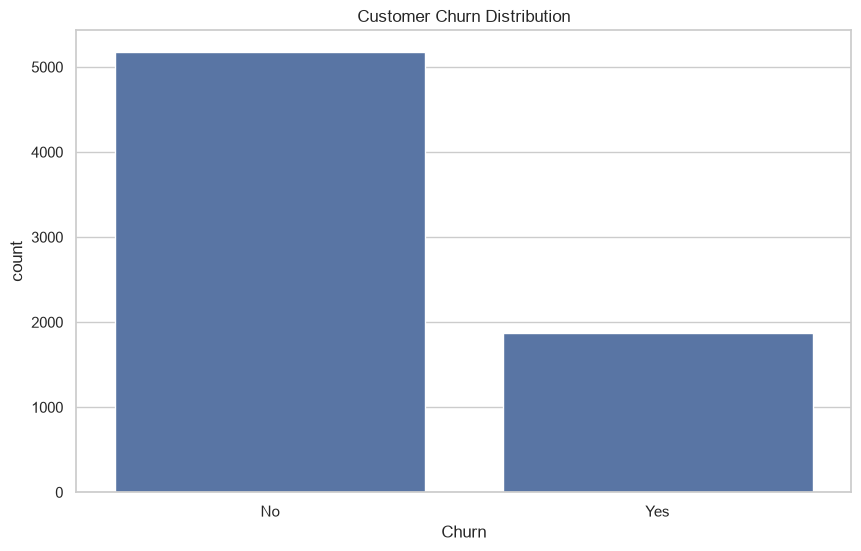

In [239]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

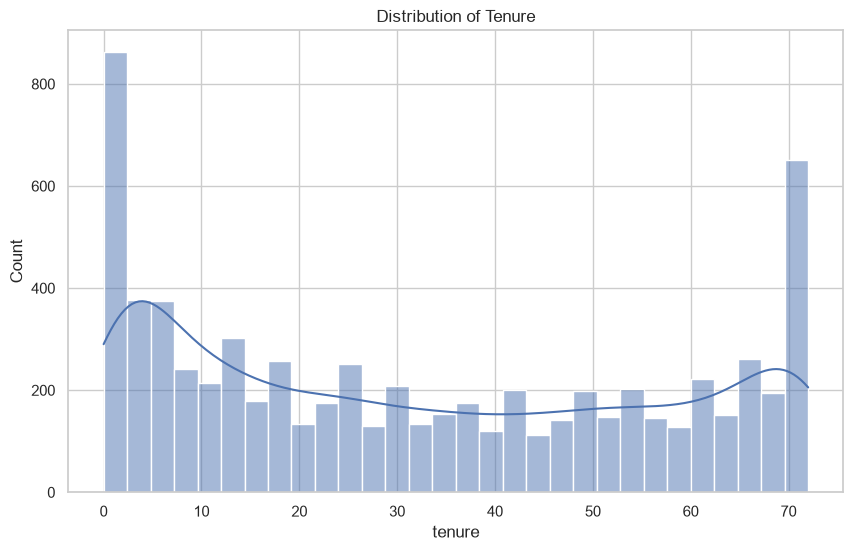

In [235]:
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribution of Tenure")
plt.show()

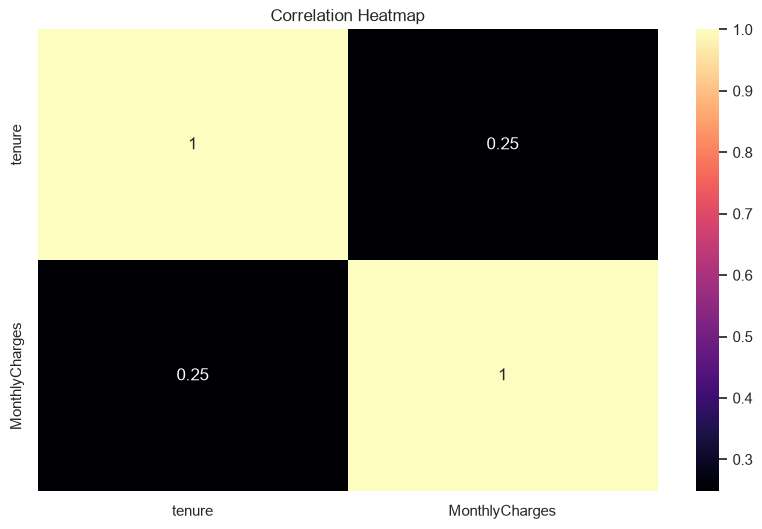

In [236]:
numeric_df = df.select_dtypes(include=["int64", "float64"])    #اختار عواميد الارقام بس   
sns.heatmap(numeric_df.corr(), annot=True, cmap="magma")
plt.title("Correlation Heatmap")
plt.show()

Train/Test Split